In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import sys

sys.path.append('/Users/leonardosantoro/Documents/GitHub/RiemannianEB/src')
from utils import *

In [2]:
plt.rcParams.update({'font.size': 10,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})
sphere = Hypersphere(dim=2)

# Function to plot spherical coordinates (theta, phi) to Mollweide lon/lat projection
def scatter_mollwide(X, ax, color, alpha=.5, s=5, lw=.5):
    X_sph = sphere.extrinsic_to_spherical(X)
    theta = X_sph[:, 0]  # colatitude
    phi = X_sph[:, 1]    # longitude

    # Convert to Mollweide coordinates
    phi_mw = phi - np.pi           # shift longitude from [0, 2π] to [-π, π]
    theta_mw = np.pi/2 - theta     # convert colatitude to latitude [-π/2, π/2]

    # Plot with color parameter
    ax.scatter(phi_mw, theta_mw, s=s, alpha=alpha, color=color)
    ax.grid(True, color='gray', lw=lw)
    return None

In [7]:
n_samples = 1000
M = 5
rho = 0.05
sigma2 = .1
kappa = 10
num_nodes = 3 
G_params = {'num_nodes': num_nodes, 'kappa': kappa}
def sample_G(n_samples,G_params):
    num_modes, kappa  = G_params['num_nodes'], G_params['kappa']
    if num_modes == 1:
        mus = np.array([[0, 0, 1]])
    elif num_modes == 2:
        mus = np.array([[0, 0, 1], [0, 0, -1]])
    else:
        # Use Fibonacci lattice for evenly distributed points
        indices = np.arange(num_modes)
        phi = np.arccos(1 - 2 * (indices + 0.5) / num_modes)
        theta = np.pi * (1 + 5**0.5) * indices
        
        mus = np.stack([
            np.sin(phi) * np.cos(theta),
            np.sin(phi) * np.sin(theta),
            np.cos(phi)
        ], axis=-1)
    
    Theta = np.vstack([ sphere.random_von_mises_fisher(kappa=kappa, mu=mu, n_samples=n_samples // num_modes) for mu in mus])
    if len(Theta) < n_samples:
        extra_samples = sphere.random_von_mises_fisher(kappa=kappa, mu=mus[0], n_samples=n_samples - len(Theta))
        Theta = np.vstack([Theta, extra_samples])
    return Theta


Theta = sample_G(n_samples, G_params)
X = sphere.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)
delta = denoiser('S2', X, M, rho, sigma2, X)


# Sampling

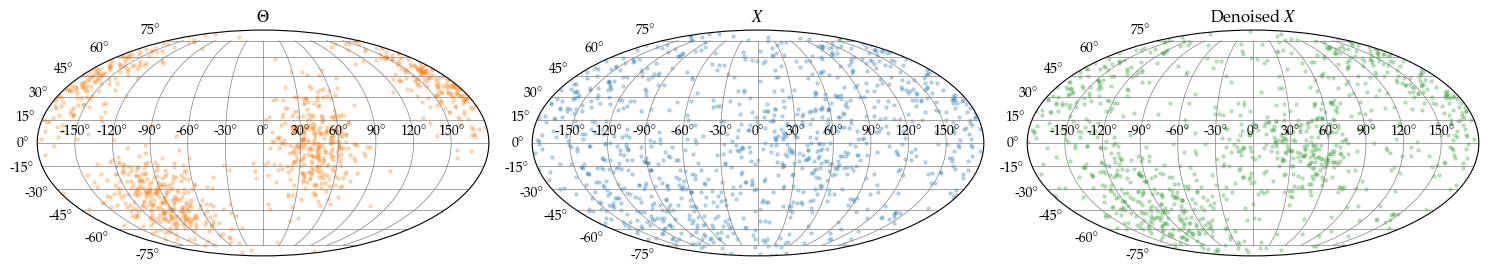

Naive Loss: 0.5482
Denoised Loss: 0.4926


In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': 'mollweide'})

# Left plot: Theta
scatter_mollwide(Theta, axs[0], color='C1', alpha=0.25)
axs[0].set_title('$\\Theta$')

# Central plot: X
scatter_mollwide(X, axs[1], color='C0', alpha=0.25)  # Changed axs[0] to axs[1]
axs[1].set_title('$X$')

# Right plot: Denoised points
scatter_mollwide(delta, axs[2], color='C2', alpha=0.25)
axs[2].set_title('Denoised $X$')

plt.tight_layout()
plt.show()

loss_T = (sphere.metric.dist_broadcast(delta, Theta).ravel()**2).mean()      
loss_N = (sphere.metric.dist_broadcast(X, Theta).ravel()**2).mean()
print(f'Naive Loss: {loss_N:.4f}')
print(f'Denoised Loss: {loss_T:.4f}')

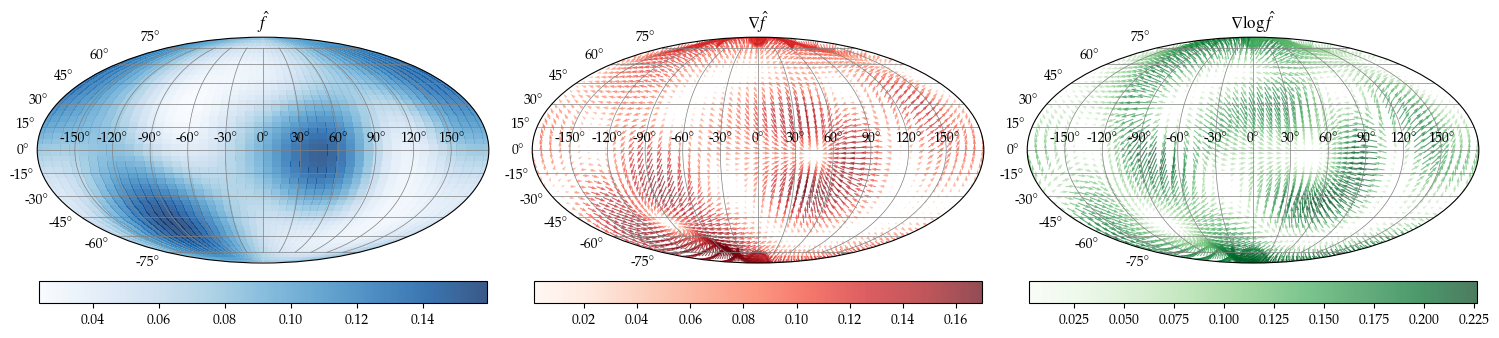

In [9]:
# Grid on S^2 (theta = colatitude, phi = longitude)
res_lat = 50
res_lon = 50
grid_theta, grid_phi = np.meshgrid(
    np.linspace(0, np.pi, res_lat),        # colatitude
    np.linspace(0, 2*np.pi, res_lon)      # longitude
)
X_grid = np.stack([
    np.sin(grid_theta) * np.cos(grid_phi),
    np.sin(grid_theta) * np.sin(grid_phi),
    np.cos(grid_theta)
], axis=-1).reshape(-1,3)

X_grid, hat_f, hat_grad_f = density_estimate('S2', X, M, X_grid)
hat_score = sigma2*  hat_grad_f / np.maximum(hat_f[:, np.newaxis], rho)
# -------------------------------------------------- PLOTTING -------------------------------------------------- #
fig, axs = plt.subplots( 1, 3,figsize=(15, 5), subplot_kw={'projection': 'mollweide'})
grid_phi_mw = (grid_phi - np.pi)          # longitude in [-pi, pi]
grid_theta_mw = (np.pi/2 - grid_theta)    # latitude in [-pi/2, pi/2]
# Plot estimated density --------------------------------------------------
axs[0].grid(True, color='gray', lw=0.5)
axs[0].set_title(r'$\hat f$')
im_f = axs[0].pcolormesh(grid_phi_mw, grid_theta_mw, 
                         hat_f.reshape(res_lat, res_lon),
                         alpha=0.8,shading='auto',cmap='Blues')
fig.colorbar(im_f, ax=axs[0], orientation='horizontal', fraction=0.05, pad=0.04)
# Plot gradient --------------------------------------------------
axs[1].grid(True, color='gray', lw=0.5)
axs[1].set_title(r'$\nabla \hat f$')
hat_grad_f_reshaped = hat_grad_f.reshape(res_lat, res_lon, 3)
e_theta = np.stack([ 
    np.cos(grid_theta) * np.cos(grid_phi), np.cos(grid_theta) * np.sin(grid_phi), -np.sin(grid_theta)
                ], axis=-1)
e_phi = np.stack([
     -np.sin(grid_phi), np.cos(grid_phi), np.zeros_like(grid_phi)
                    ], axis=-1)
grad_theta = -np.sum(hat_grad_f_reshaped * e_theta, axis=-1) # Project gradient onto tangent directions
grad_phi = np.sum(hat_grad_f_reshaped * e_phi, axis=-1)
skip = 1  # Subsample for clearer visualization
im_grad = axs[1].quiver(grid_phi_mw[::skip, ::skip], grid_theta_mw[::skip, ::skip],
              grad_phi[::skip, ::skip], grad_theta[::skip, ::skip],
              np.sqrt(grad_theta**2 + grad_phi**2)[::skip, ::skip],
              scale= 5, cmap='Reds', alpha=0.7)

fig.colorbar(im_grad, ax=axs[1], orientation='horizontal', fraction=0.05, pad=0.04)
# Plot score --------------------------------------------------
hat_score_reshaped = hat_score.reshape(res_lat, res_lon, 3)
grad_theta_score = -np.sum(hat_score_reshaped * e_theta, axis=-1) # Project score onto tangent directions
grad_phi_score = np.sum(hat_score_reshaped * e_phi, axis=-1)

axs[2].grid(True, color='gray', lw=0.5)
axs[2].set_title(r'$\nabla \log \hat f$')

skip = 1  # Subsample for clearer visualization
im_score = axs[2].quiver(grid_phi_mw[::skip, ::skip], grid_theta_mw[::skip, ::skip],
              grad_phi_score[::skip, ::skip], grad_theta_score[::skip, ::skip],
              np.sqrt(grad_theta_score**2 + grad_phi_score**2)[::skip, ::skip],
              scale= 5, cmap='Greens', alpha=0.7)
fig.colorbar(im_score, ax=axs[2], orientation='horizontal', fraction=0.05, pad=0.04)
plt.tight_layout()
plt.show()

# Distribution visualisation

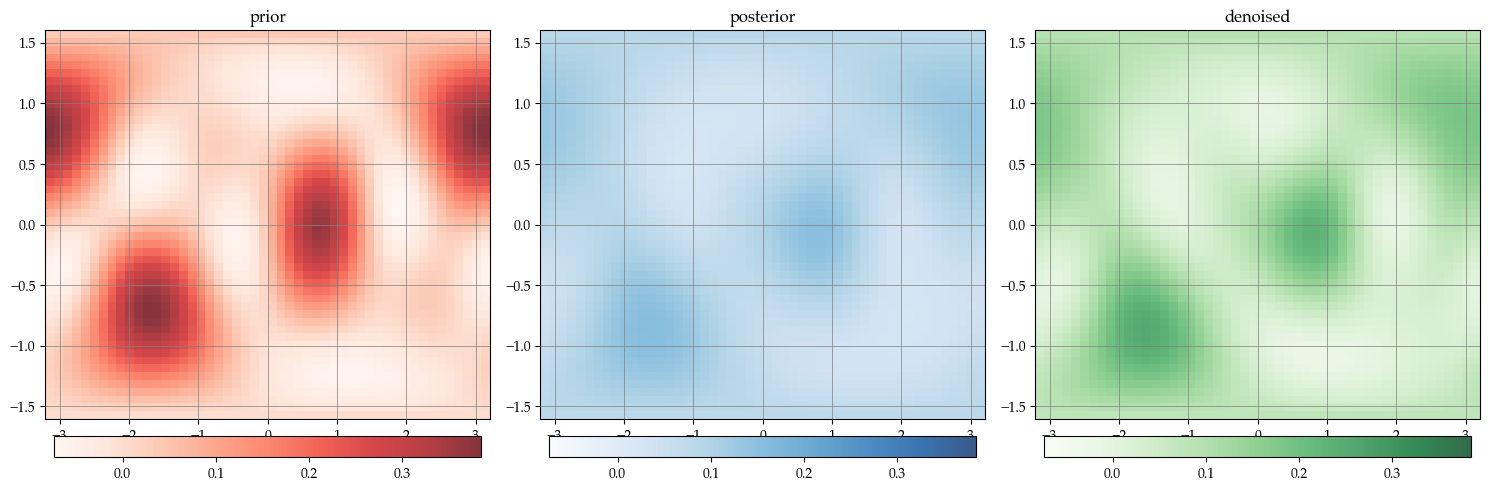

In [10]:
# Grid on S^2 (theta = colatitude, phi = longitude)
res_lat = 50
res_lon = 50
grid_theta, grid_phi = np.meshgrid(
    np.linspace(0, np.pi, res_lat),        # colatitude
    np.linspace(0, 2*np.pi, res_lon)      # longitude
)
X_grid = np.stack([
    np.sin(grid_theta) * np.cos(grid_phi),
    np.sin(grid_theta) * np.sin(grid_phi),
    np.cos(grid_theta)
], axis=-1).reshape(-1,3)

# Compute densities
X_grid, hat_f_post, _ = density_estimate('S2', X, M, X_grid)
X_grid, hat_f_prior, _  = density_estimate('S2', Theta, M, X_grid)
X_grid, hat_f_delta, _ = density_estimate('S2', delta, M, X_grid)

# Determine common color scale
vmin = min(hat_f_prior.min(), hat_f_post.min(), hat_f_delta.min())
vmax = max(hat_f_prior.max(), hat_f_post.max(), hat_f_delta.max())

# -------------------------------------------------- PLOTTING -------------------------------------------------- #
fig, axs = plt.subplots(1, 3, figsize=(15, 5), 
                        # subplot_kw={'projection': 'mollweide'}
                        )
grid_phi_mw = grid_phi - np.pi          # longitude in [-pi, pi]
grid_theta_mw = np.pi/2 - grid_theta    # latitude in [-pi/2, pi/2]

# prior
axs[0].grid(True, color='gray', lw=0.5)
axs[0].set_title('prior')
im = axs[0].pcolormesh(grid_phi_mw, grid_theta_mw, 
                       hat_f_prior.reshape(res_lat, res_lon),
                       alpha=0.8, shading='auto', cmap='Reds',
                       vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axs[0], orientation='horizontal', fraction=0.05, pad=0.04)

# posterior
axs[1].grid(True, color='gray', lw=0.5)
axs[1].set_title('posterior')
im = axs[1].pcolormesh(grid_phi_mw, grid_theta_mw, 
                       hat_f_post.reshape(res_lat, res_lon),
                       alpha=0.8, shading='auto', cmap='Blues',
                       vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axs[1], orientation='horizontal', fraction=0.05, pad=0.04)

# denoised
axs[2].grid(True, color='gray', lw=0.5)
axs[2].set_title('denoised')
im = axs[2].pcolormesh(grid_phi_mw, grid_theta_mw, 
                       hat_f_delta.reshape(res_lat, res_lon),
                       alpha=0.8, shading='auto', cmap='Greens',
                       vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axs[2], orientation='horizontal', fraction=0.05, pad=0.04)

plt.tight_layout()
plt.show()


# Monte Carlo estimate of Naive and Denoised Risk

In [22]:
def MCrun(sample_G, n, sigma2, M , rho):
    sphere = Hypersphere(2)
    Theta = sample_G(n, kappa)
    X = sphere.random_riemannian_normal(Theta, 1./sigma2, n)
    delta = denoiser('S2', X, M, rho, sigma2, X)
    loss_T = (sphere.metric.dist_broadcast(delta, Theta).ravel()**2).mean()      
    loss_N = (sphere.metric.dist_broadcast(X, Theta).ravel()**2).mean()
    return loss_T, loss_N

MC runs: 100%|██████████| 10/10 [00:03<00:00,  2.83it/s]


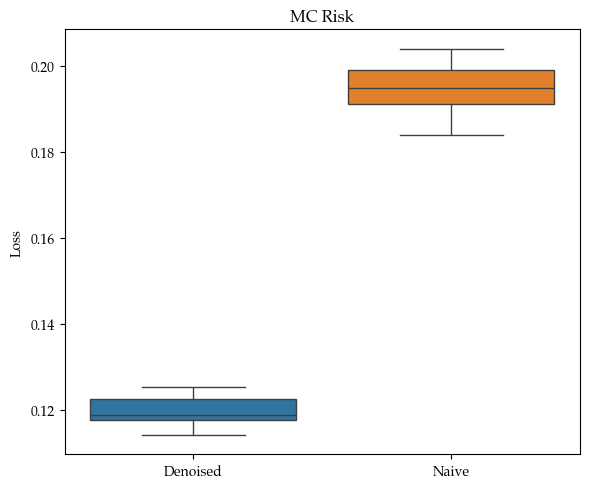

In [29]:
NMC = 10
loss_T_all = np.zeros((NMC, n_samples))
loss_N_all = np.zeros((NMC, n_samples))
for imc in tqdm(range(NMC), total = NMC, desc = 'MC runs'):
    loss_T_all[imc,:], loss_N_all[imc,:] = MCrun(sample_G, n_samples, sigma2, M, rho)


# --- Plot boxplots of losses
fig, ax = plt.subplots(figsize=(6, 5))
data_to_plot = pd.DataFrame({
    'Denoised': loss_T_all.ravel(),
    'Naive': loss_N_all.ravel(),
})
sns.boxplot(data=data_to_plot, ax=ax)
ax.set_ylabel('Loss')
ax.set_title('MC Risk')
plt.tight_layout()
plt.show()